# Feature detection

## Harris Corner detection

As always we start with the imports

In [574]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

To start, we will use the same checkerboard image as earlier.

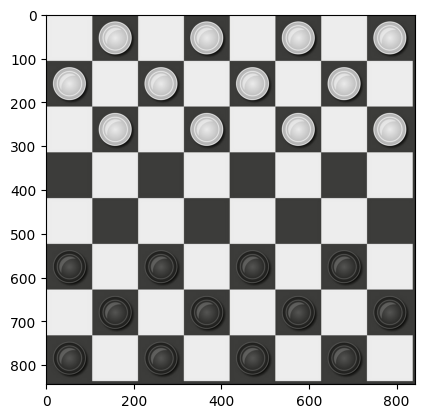

In [575]:
img = cv2.imread('checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2a
Fill in the missing code in the next block. We would like to detect the corners of the image using the OpenCV function [`cv2.cornerHarris`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345). Afterwards we want to draw the location of the detected corners on the image and display it.

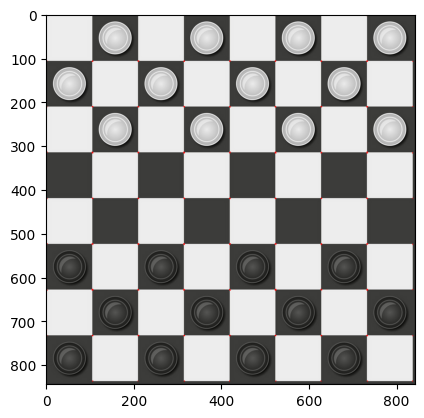

In [576]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

### Insert Harris Corner detector here ###
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

### Draw the detected corners in the original image here ###
# Threshold: mark in red where response is strong
img[dst > 0.01 * dst.max()] = [255, 0, 0]

# Display image
plt.imshow(img)


## Shi-Tomasi
Next we will try the Shi-Tomasi feature detection method. In OpenCV, that method is implemented as [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541). 
Let's start with a different image this time.

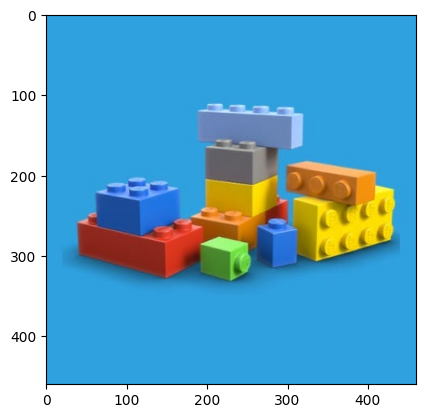

In [577]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2b
Just like the previous exercise, detect the corners of the image by inserting the missing code, this time using the Shi-Tomasi (good features to track) method. Draw the detected corners on the image. Check the documentation of the function for help.

(np.float64(-0.5), np.float64(459.5), np.float64(459.5), np.float64(-0.5))

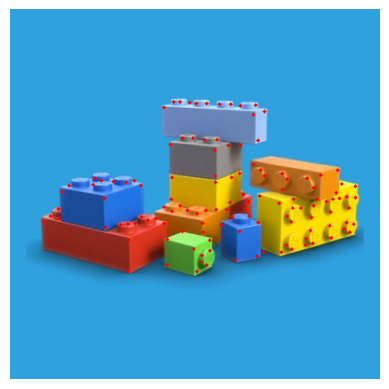

In [578]:

# convert once to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# >>> choose your own threshold here <<<
q = 0.05    # qualityLevel, try 0.05 – 0.20
d = 8        # minDistance between corners (pixels)

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=200,
    qualityLevel=q,
    minDistance=d,
    blockSize=9
)

out = img.copy()
if corners is not None:
    for p in corners:
        x, y = map(int, p.ravel())
        cv2.circle(out, (x, y), 2, (255, 0, 0), -1)

plt.imshow(out); plt.axis('off')


### Exercise 2c
Do a Harris corner detection on the same Lego image and compare the result with the Shi-Tomasi image.

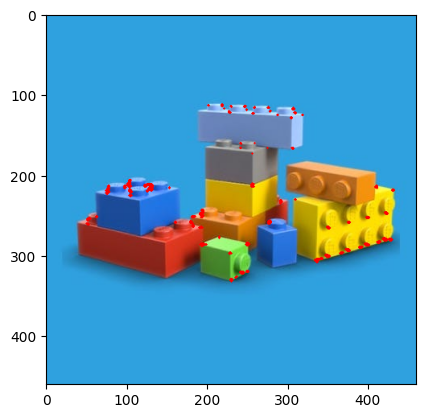

In [579]:


gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(np.float32(gray), (3,3), 0)


dst = cv2.cornerHarris(gray, blockSize=4, ksize=3, k=0.04)


thr = 0.06                

out = img.copy()
ys, xs = np.where(dst > thr * dst.max())
for x, y in zip(xs, ys):
    cv2.circle(out, (int(x), int(y)),1, (255, 0, 0), -1)

plt.imshow(out)
